In [260]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [261]:
df = pd.read_csv('CarPricePrediction.csv')

In [262]:
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner


In [263]:
df.tail(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


In [264]:
df.shape

(4340, 8)

In [265]:
df.isnull().sum().sum()

0

In [266]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [267]:
print(df.dtypes)

name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object


In [268]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include='object').columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['year', 'selling_price', 'km_driven'], dtype='object')
Categorical columns: Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')


In [269]:
corr_matrix = df.corr(numeric_only = True)
print(corr_matrix)

                   year  selling_price  km_driven
year           1.000000       0.413922  -0.419688
selling_price  0.413922       1.000000  -0.192289
km_driven     -0.419688      -0.192289   1.000000


In [270]:
# how features affect the car price

In [271]:
# selling price and km driven

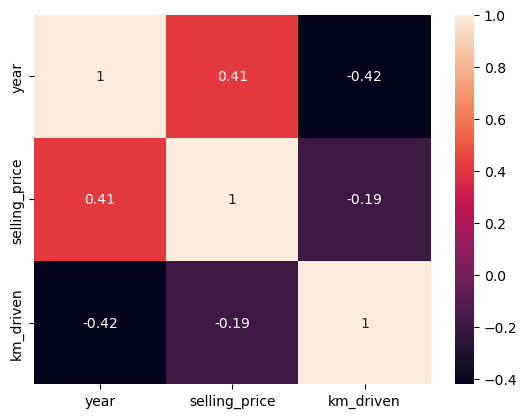

In [272]:
sns.heatmap(corr_matrix, annot=True)
plt.show()

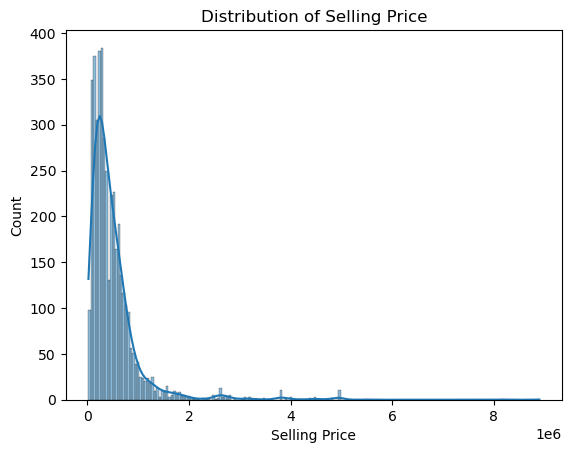

In [273]:
sns.histplot(df['selling_price'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()

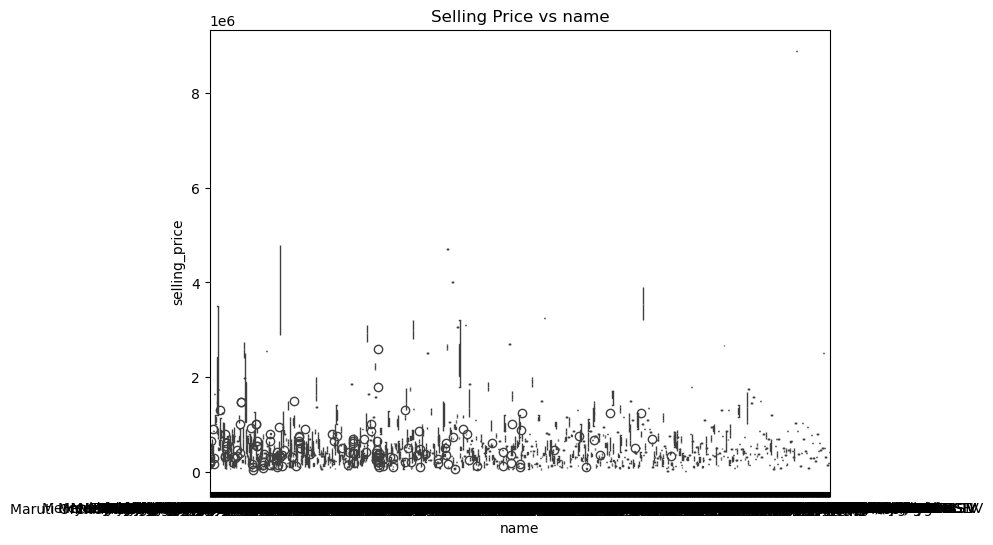

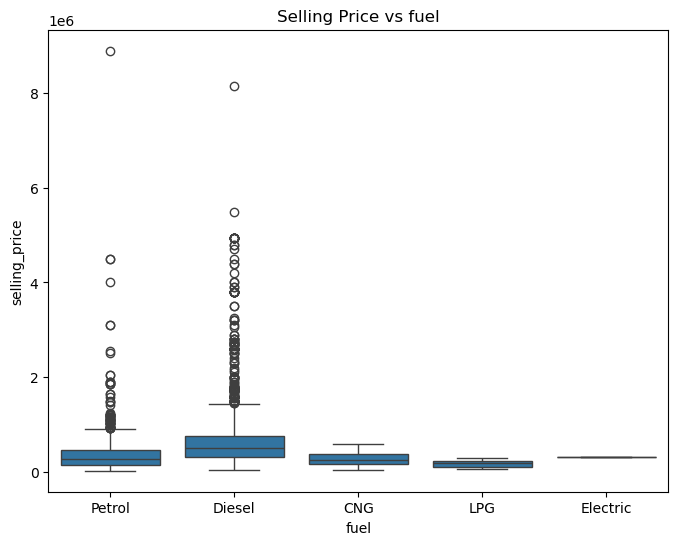

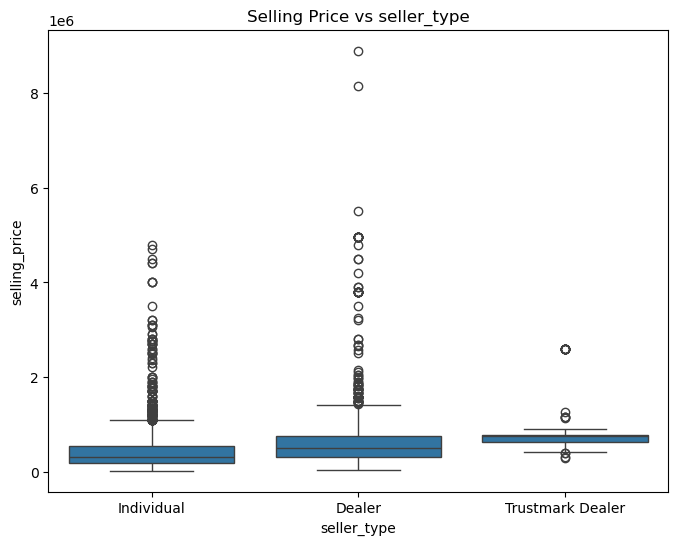

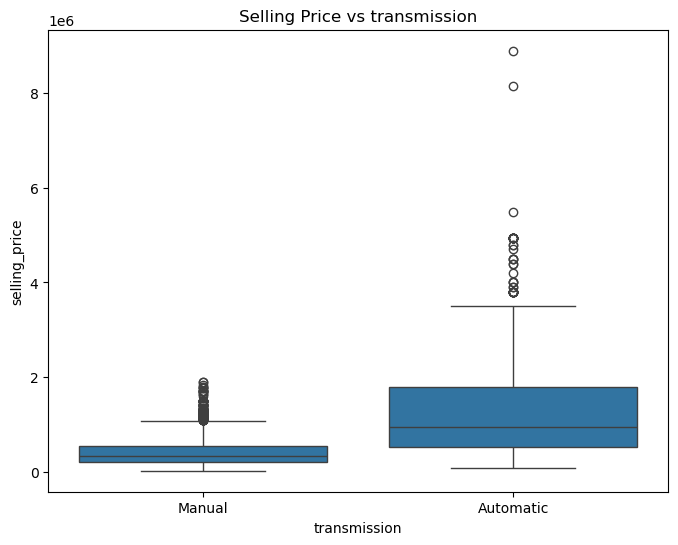

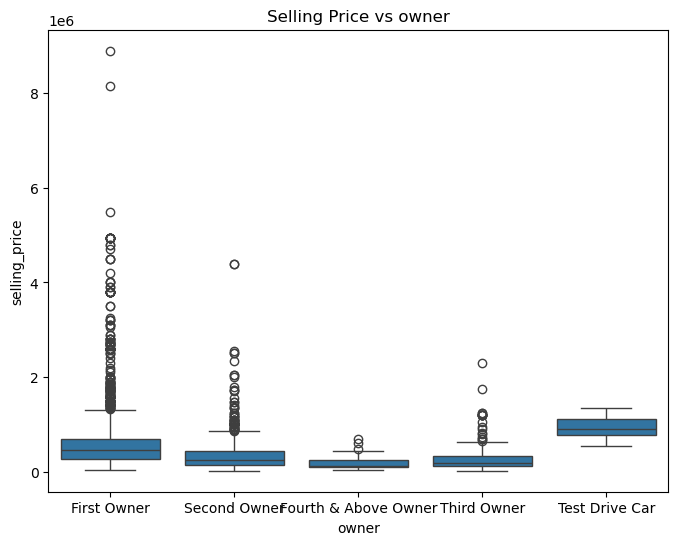

In [274]:
# Boxplot for categorical features vs price
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=col, y='selling_price', data=df)
    plt.title(f'Selling Price vs {col}')
    plt.show()

Text(0, 0.5, 'Frequency')

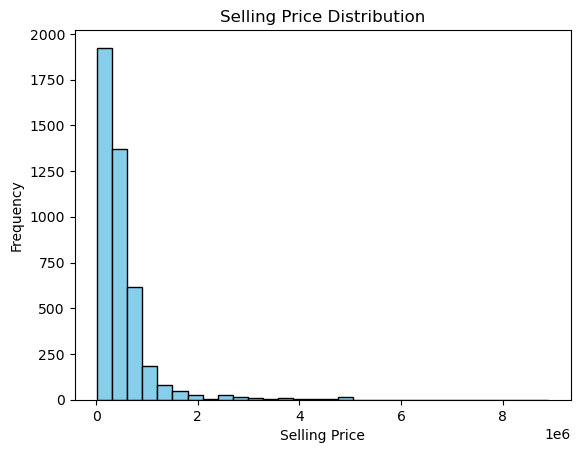

In [275]:
plt.hist(df['selling_price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

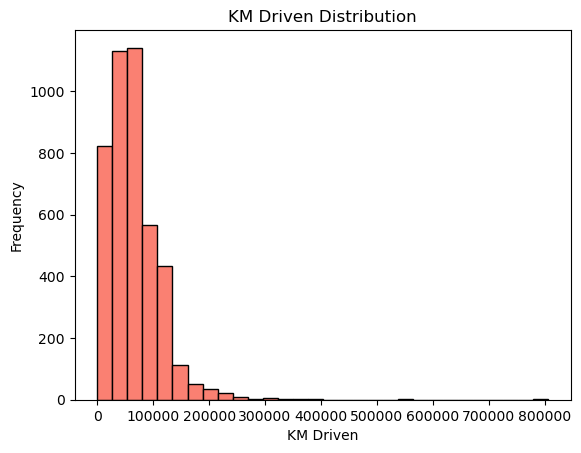

In [276]:
plt.hist(df['km_driven'], bins=30, color='salmon', edgecolor='black')
plt.title('KM Driven Distribution')
plt.xlabel('KM Driven')
plt.ylabel('Frequency')

In [277]:
# Encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [278]:
# Define features (X) and target (y)
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [279]:
# Scale numerical features
scaler = StandardScaler()
X[numerical_cols.drop('selling_price')] = scaler.fit_transform(X[numerical_cols.drop('selling_price')])

In [280]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [281]:
X_train

,name,year,km_driven,fuel,seller_type,transmission,owner
227,691,0.927485,-0.990931,1,1,1,0
964,971,1.164741,-0.347689,1,1,1,0
2045,793,-0.021539,-0.883724,4,1,1,2
1025,51,-0.496051,0.081139,1,1,1,0
4242,1016,0.927485,0.124022,1,0,1,0
...,...,...,...,...,...,...,...
3444,1401,-1.682330,-0.347689,1,1,1,0
466,1236,-0.496051,0.295553,1,1,1,0
3092,859,0.690229,-0.326248,1,0,1,0
3772,883,-0.021539,0.295553,1,1,1,0


In [282]:
y_test

3978    165000
1448    250000
2664    120000
17      450000
1634    730000
         ...  
3468    130000
3164    350000
416     150000
1616    650000
2480    575000
Name: selling_price, Length: 868, dtype: int64

In [283]:
from sklearn.linear_model import LinearRegression

In [284]:
lr = LinearRegression()

In [285]:
lr.fit(X_train, y_train)

LinearRegression()

In [286]:
y_pred = lr.predict(X_test)

In [287]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [288]:
mean_absolute_error(y_test, y_pred)

221820.84345082458

In [289]:
mse = mean_squared_error(y_test, y_pred)
mse

184332080354.49106

In [290]:
np.sqrt(mse)

429339.12045665144

In [291]:
r2 = r2_score(y_test, y_pred)
r2

0.3959697625888199

In [292]:
1-((1-r2)*(40-1)/ (40-1-2))

0.3633194794855128

In [293]:
print("Model Interpretation:")
print("1. Strengths: Linear Regression is simple, interpretable, and works well for linear relationships.")
print("2. Limitations: Assumes linearity, may not capture complex patterns.")
print("3. Overfitting/Underfitting: Check R² and residuals; low R² may indicate underfitting.")

Model Interpretation:
1. Strengths: Linear Regression is simple, interpretable, and works well for linear relationships.
2. Limitations: Assumes linearity, may not capture complex patterns.
3. Overfitting/Underfitting: Check R² and residuals; low R² may indicate underfitting.


In [294]:
# Removing outliers

In [295]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

In [297]:
df = remove_outliers(df, 'selling_price')

In [299]:
# Thank you